In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# test how well we approximate A even if we run env with coca dynamic
# modify the network to include dynamics / propagation features

In [3]:
import os, sys


def get_dir_n_levels_up(path, n):
    # Go up n levels from the given path
    for _ in range(n):
        path = os.path.dirname(path)
    return path

proj_root = get_dir_n_levels_up(os.path.abspath("__file__"), 3)
sys.path.append(proj_root)

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from rl_envs_forge.envs.network_graph.graph_utils import compute_laplacian, compute_eigenvector_centrality
from opinion_dynamics.utils.env_setup import EnvironmentFactory
from opinion_dynamics.identify import GraphIdentifierEnv, train_graph_identifier, pairs_from_intermediate, v_from_P
from opinion_dynamics.baseline import centrality_based_continuous_control


In [4]:
def run_single_paper_experiment_per_campaign_budget(
    *,
    B_campaign: float = 1.0,
    num_campaigns_total: int = 5,
    lr: float = 1e-3,
    l2_lambda: float = 0.0,
    device: str = "cpu",
    update_A_each_campaign: bool = True,
):
    env_factory = EnvironmentFactory()
    env = env_factory.get_randomized_env()

    N = env.num_agents
    ubar_vec = np.asarray(env.max_u, dtype=float)

    # --- storage (boundary) ---
    states = []
    actions = []
    rewards = []
    A_hats = []
    v_hats = []

    # --- storage (fine-grained) ---
    intermediate_states = []  # list of (Ksub+1, N)
    intermediate_times  = []  # list of (Ksub+1,)

    # data buffers for learning (x_l, x_{l+1})
    buf_x, buf_y = [], []

    # reset env
    x0, info = env.reset()
    states.append(x0.copy())

    # init learner (your model)
    gi = GraphIdentifierEnv(N=N, s=env.t_s, l2_lambda=l2_lambda, zero_diag=True)

    done = False
    trunc = False

    for k in range(num_campaigns_total):
        # campaign 0 is free-fall (no control)
        if k == 0:
            uk = np.zeros(N, dtype=float)
        else:
            # ensure per-campaign budget (not global remaining)
            beta_k = min(float(B_campaign), float(ubar_vec.sum()))
            # use latest v_hat (if not fitted yet, fall back to env.centralities)
            if len(v_hats) == 0:
                v_used = env.centralities
            else:
                v_used = v_hats[-1]
            uk, _ = centrality_based_continuous_control(env, beta_k, v=v_used)

        x_next, r, done, trunc, info_k = env.step(uk)

        actions.append(uk.copy())
        rewards.append(float(r))
        states.append(x_next.copy())

        inter = info_k.get("intermediate_states", None)
        if inter is None:
            raise RuntimeError("env.step did not return info['intermediate_states']")
        inter = np.asarray(inter, dtype=float)
        intermediate_states.append(inter.copy())

        # Build the matching times for this campaign
        Ksub = inter.shape[0] - 1
        t0 = k * float(env.t_campaign)
        times_k = t0 + np.arange(Ksub + 1) * float(env.t_s)
        intermediate_times.append(times_k)

        # collect (x_l, x_{l+1}) pairs from intermediate states for identification
        Xp, Yp = pairs_from_intermediate(inter)
        buf_x.append(Xp)
        buf_y.append(Yp)

        # update A_hat online (paper-style)
        if update_A_each_campaign:
            X = np.concatenate(buf_x, axis=0)
            Y = np.concatenate(buf_y, axis=0)
            A_hat = train_graph_identifier(gi, X, Y, lr=lr, device=device)

            A_hats.append(A_hat)
            v_hat = compute_eigenvector_centrality(compute_laplacian(A_hat))
            v_hats.append(v_hat)

        if done or trunc:
            break

    return {
        "env": env,
        "states": np.array(states),              # (K+1, N)
        "actions": np.array(actions),            # (K, N)
        "rewards": np.array(rewards),            # (K,)
        "A_hats": A_hats,                        # list
        "v_hats": v_hats,                        # list
        "intermediate_states": np.array(intermediate_states),  # (K, Ksub+1, N)
        "intermediate_times": np.array(intermediate_times),    # (K, Ksub+1)
    }

# -----------------------------
# Helpers: plotting (impulse look) + heatmap cell grid
# -----------------------------
def plot_impulse_node_trajectories(inter_states, inter_times, title, ylim=(0, 1)):
    """
    inter_states: (K, Ksub+1, N)
    inter_times:  (K, Ksub+1)
    """
    inter_states = np.asarray(inter_states)
    inter_times  = np.asarray(inter_times)

    t = inter_times.reshape(-1)
    x = inter_states.reshape(-1, inter_states.shape[-1])

    plt.figure(figsize=(10, 4))
    for i in range(x.shape[1]):
        plt.plot(t, x[:, i], linewidth=1)
    plt.xlabel("time")
    plt.ylabel("opinion $x_i$")
    plt.title(title)
    plt.grid(True, alpha=0.25)
    plt.ylim(*ylim)
    plt.show()


def show_matrix_with_cell_grid(
    A,
    title,
    *,
    figsize=(8, 6),
    vmin=None,
    vmax=None,
    grid_color="#C8C8C8",   # muted grey
    grid_alpha=0.35,        # make it softer
    grid_lw=0.6,            # thin lines
    show_ticks=True,
):
    A = np.asarray(A)
    nrows, ncols = A.shape

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(A, aspect="auto", vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

    # put grid lines between cells
    ax.set_xticks(np.arange(-0.5, ncols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, nrows, 1), minor=True)
    ax.grid(which="minor", color=grid_color, linestyle="-", linewidth=grid_lw, alpha=grid_alpha)

    # hide minor tick marks (but keep the grid)
    ax.tick_params(which="minor", bottom=False, left=False)

    if show_ticks:
        ax.set_xlabel("j")
        ax.set_ylabel("i")
    else:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")

    plt.tight_layout()
    plt.show()


# -----------------------------
# Helper: graph sanity
# -----------------------------
def graph_sanity(A):
    A = np.asarray(A, dtype=float)
    diag_max = float(np.max(np.abs(np.diag(A))))
    rs = A.sum(axis=1)
    asym = float(np.linalg.norm(A - A.T) / (np.linalg.norm(A) + 1e-12))
    edges = int(np.sum(A > 1e-12))

    G = nx.from_numpy_array(A, create_using=nx.DiGraph)
    sccs = list(nx.strongly_connected_components(G))
    sink_sizes = []
    for S in sccs:
        is_sink = True
        for u in S:
            for v in G.successors(u):
                if v not in S:
                    is_sink = False
                    break
            if not is_sink:
                break
        if is_sink:
            sink_sizes.append(len(S))

    return dict(
        diag_max=diag_max,
        row_sum_min=float(rs.min()),
        row_sum_mean=float(rs.mean()),
        row_sum_max=float(rs.max()),
        asym=asym,
        edges=edges,
        sink_sizes=sink_sizes,
        has_singleton_sink=any(sz == 1 for sz in sink_sizes),
    )


# -----------------------------
# Helper: oracle rollout with intermediate states
# -----------------------------
def rollout_with_policy_intermediate(env_template, x0, *, num_campaigns_total, B_campaign, v_used, mode="oracle"):
    """
    mode:
      - "oracle": campaign0 is zero-control, then centrality-based control using v_used each campaign
      - "nocontrol": always zero action
    Returns:
      env, states_boundaries, actions, rewards, inter_states, inter_times
    """
    EnvCls = env_template.__class__
    kwargs = dict(
        connectivity_matrix=np.array(env_template.connectivity_matrix, copy=True),
        num_agents=env_template.num_agents,
        max_u=np.array(env_template.max_u, copy=True),
        desired_opinion=float(env_template.desired_opinion),
        t_campaign=float(env_template.t_campaign),
        t_s=float(env_template.t_s),
        dynamics_model=str(env_template.dynamics_model),
        control_resistance=np.array(env_template.control_resistance, copy=True),
        max_steps=int(getattr(env_template, "max_steps", 10_000)),
        opinion_end_tolerance=float(getattr(env_template, "opinion_end_tolerance", 0.01)),
        control_beta=float(getattr(env_template, "control_beta", 0.4)),
        normalize_reward=bool(getattr(env_template, "normalize_reward", False)),
        terminal_reward=float(getattr(env_template, "terminal_reward", 0.0)),
        terminate_when_converged=bool(getattr(env_template, "terminate_when_converged", True)),
        seed=int(getattr(env_template, "seed", 0)) if getattr(env_template, "seed", None) is not None else None,
    )
    env = EnvCls(**kwargs)

    N = env.num_agents
    ubar_vec = np.asarray(env.max_u, dtype=float)

    x, _ = env.reset()
    env.opinions = np.array(x0, copy=True)

    states = [env.opinions.copy()]
    actions = []
    rewards = []

    inter_states = []
    inter_times  = []

    for k in range(num_campaigns_total):
        if mode == "nocontrol" or (k == 0):
            uk = np.zeros(N, dtype=float)
        else:
            beta_k = min(float(B_campaign), float(ubar_vec.sum()))
            uk, _ = centrality_based_continuous_control(env, beta_k, v=v_used)

        x_next, r, done, trunc, info = env.step(uk)

        actions.append(uk.copy())
        rewards.append(float(r))
        states.append(x_next.copy())

        inter = info.get("intermediate_states", None)
        if inter is None:
            raise RuntimeError("env.step did not return info['intermediate_states']")
        inter = np.asarray(inter)
        inter_states.append(inter.copy())

        Ksub = inter.shape[0] - 1
        t0 = k * float(env.t_campaign)
        times_k = t0 + np.arange(Ksub + 1) * float(env.t_s)
        inter_times.append(times_k)

        if done or trunc:
            break

    return env, np.array(states), np.array(actions), np.array(rewards), np.array(inter_states), np.array(inter_times)


[fit] step=0 mae=0.03563 | A_row_sum min/mean/max=1/1/1 | A min/max=0/0.134
[fit] step=2000 mae=0.007101 | A_row_sum min/mean/max=1/1/1 | A min/max=0/0.479
[fit] step=4000 mae=0.00322 | A_row_sum min/mean/max=1/1/1 | A min/max=0/0.687
[fit] step=6000 mae=0.002004 | A_row_sum min/mean/max=1/1/1 | A min/max=0/0.762
[fit] step=8000 mae=0.001286 | A_row_sum min/mean/max=1/1/1 | A min/max=0/0.8
[fit] step=0 mae=0.00369 | A_row_sum min/mean/max=1/1/1 | A min/max=0/0.815
[fit] step=2000 mae=0.00126 | A_row_sum min/mean/max=1/1/1 | A min/max=0/0.75
[fit] step=0 mae=0.00161 | A_row_sum min/mean/max=1/1/1 | A min/max=0/0.732
[fit] step=0 mae=0.001062 | A_row_sum min/mean/max=1/1/1 | A min/max=0/0.738
=== EXP SUMMARY ===
N=15 | t_s=0.5 | t_campaign=2 | B_campaign=1.0 | campaigns=5
Per-campaign spend (learned): [0. 1. 1. 1. 1.]

=== GRAPH SANITY (TRUE) ===
diag_max: 0.0
row_sum_min: 0.9999999999999999
row_sum_mean: 1.0
row_sum_max: 1.0
asym: 0.9594543642240806
edges: 45
sink_sizes: [15]
has_single

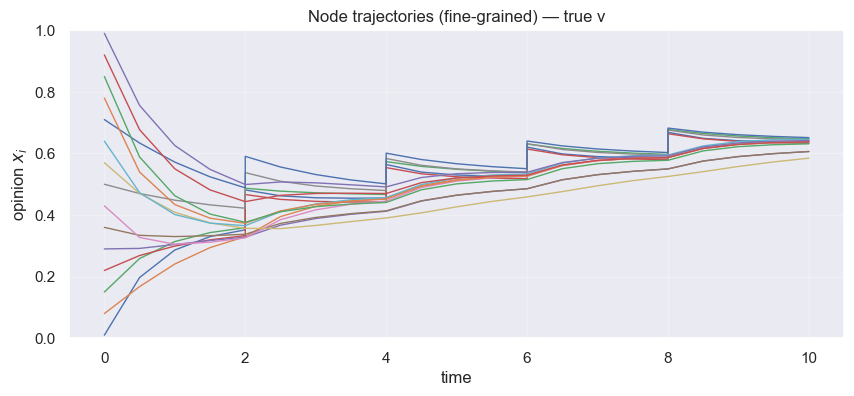

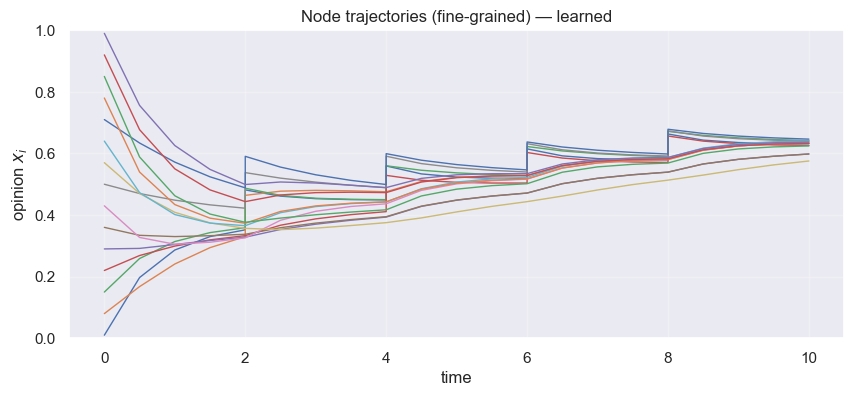


=== CENTRALITY COMPARISON (by node index) ===
L1(v_hat - v_true): 0.2516754264248432


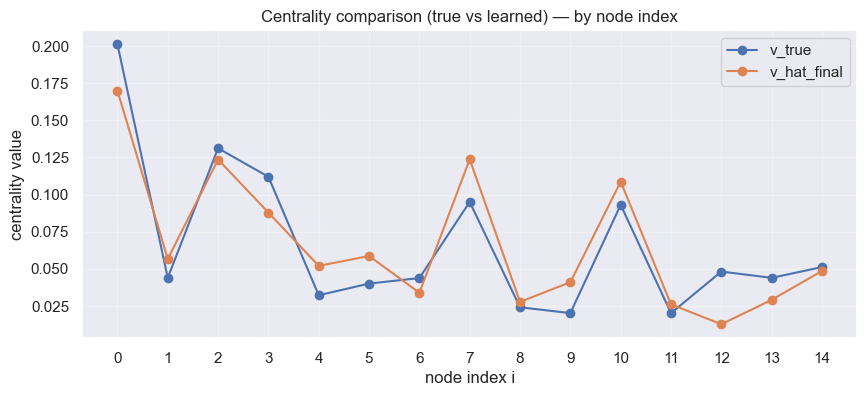

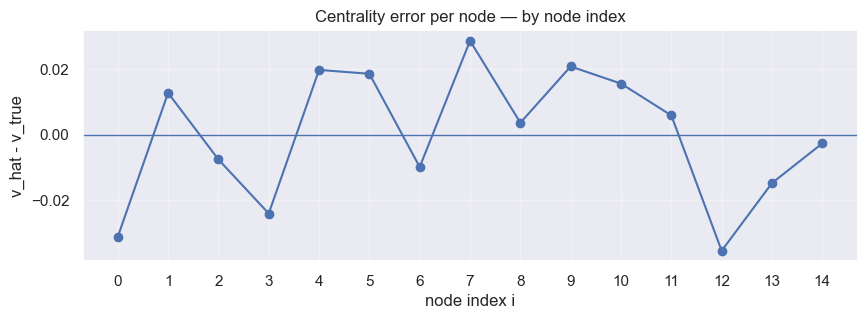

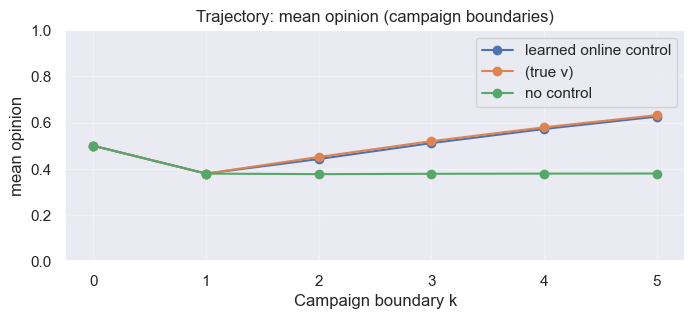

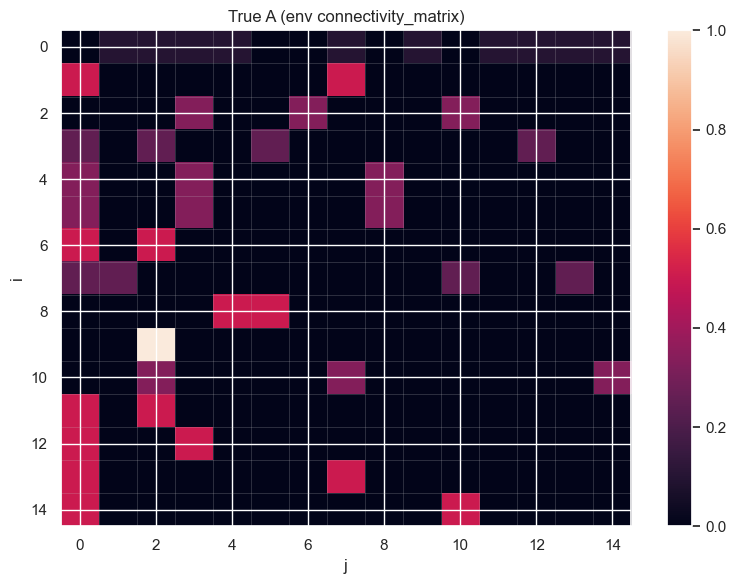

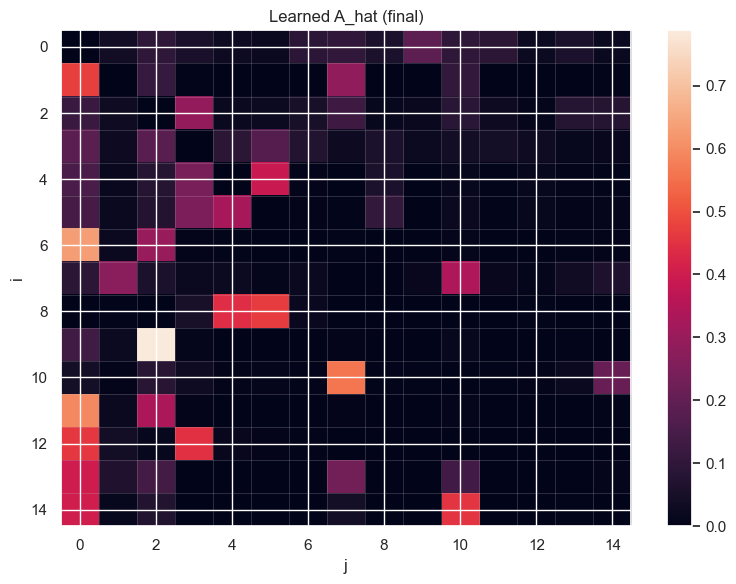

In [5]:
# =========================================================
# 1) Run ONE experiment (your online method)
# IMPORTANT: this function MUST return intermediate_states/times for the ACTUAL run.
# If yours doesn't yet, update it as discussed:
#   out["intermediate_states"], out["intermediate_times"]
# =========================================================
B_campaign = 1.0
num_campaigns_total = 5

out = run_single_paper_experiment_per_campaign_budget(
    B_campaign=B_campaign,
    num_campaigns_total=num_campaigns_total,
)

env = out["env"]
states_learn  = np.asarray(out["states"])    # (K+1, N)
actions_learn = np.asarray(out["actions"])   # (K, N)
A_hats        = out["A_hats"]                # list length = num refits

# ACTUAL learned run fine-grained trajectories
if "intermediate_states" not in out or "intermediate_times" not in out:
    raise RuntimeError(
        "Your experiment output does not include 'intermediate_states'/'intermediate_times'. "
        "Update run_single_paper_experiment_per_campaign_budget to store info['intermediate_states'] each campaign."
    )

inter_learn = np.asarray(out["intermediate_states"])  # (K, Ksub+1, N)
times_learn = np.asarray(out["intermediate_times"])   # (K, Ksub+1)

N = env.num_agents
x0 = states_learn[0].copy()
K_total = len(states_learn) - 1  # number of campaigns actually run


# -----------------------------
# 3) True graph + v_true (env-consistent)
# -----------------------------
A_true = np.asarray(env.connectivity_matrix, dtype=float)
L_true = compute_laplacian(A_true)
v_true = compute_eigenvector_centrality(L_true)


# -----------------------------
# 4) Oracle and no-control trajectories (same graph, same x0) WITH intermediate
# -----------------------------
env_or, states_or, actions_or, rewards_or, inter_or, times_or = rollout_with_policy_intermediate(
    env, x0, num_campaigns_total=K_total, B_campaign=B_campaign, v_used=v_true, mode="oracle"
)
env_nc, states_nc, actions_nc, rewards_nc, inter_nc, times_nc = rollout_with_policy_intermediate(
    env, x0, num_campaigns_total=K_total, B_campaign=B_campaign, v_used=None, mode="nocontrol"
)


# -----------------------------
# 5) Compact prints: graph sanity (true vs learned-final)
# -----------------------------
A_hat_final = np.asarray(A_hats[-1], dtype=float)
san_true = graph_sanity(A_true)
san_hat  = graph_sanity(A_hat_final)

print("=== EXP SUMMARY ===")
print(f"N={N} | t_s={env.t_s} | t_campaign={env.t_campaign} | B_campaign={B_campaign} | campaigns={K_total}")
print("Per-campaign spend (learned):", actions_learn.sum(axis=1))

print("\n=== GRAPH SANITY (TRUE) ===")
for k, v in san_true.items():
    print(f"{k}: {v}")

print("\n=== GRAPH SANITY (LEARNED FINAL) ===")
for k, v in san_hat.items():
    print(f"{k}: {v}")


# -----------------------------
# 6) Identification metrics per refit (A and v)
# -----------------------------
v_l1, A_fro, A_mae = [], [], []
for A_hat in A_hats:
    A_hat = np.asarray(A_hat, dtype=float)
    v_hat = compute_eigenvector_centrality(compute_laplacian(A_hat))
    v_l1.append(float(np.sum(np.abs(v_hat - v_true))))
    A_fro.append(float(np.linalg.norm(A_hat - A_true, ord="fro")))
    A_mae.append(float(np.mean(np.abs(A_hat - A_true))))

print("\n=== IDENTIFICATION METRICS (per refit) ===")
print("num_updates:", len(A_hats))
for i in range(len(A_hats)):
    print(f"[k={i:02d}] v_L1={v_l1[i]:.6f} | A_Fro={A_fro[i]:.6f} | A_MAE={A_mae[i]:.6f}")


# -----------------------------
# 7) Per-campaign control summary (learned)
# -----------------------------
print("\n=== LEARNED CONTROL (per campaign) ===")
for k in range(actions_learn.shape[0]):
    uk = actions_learn[k]
    spent = float(uk.sum())
    top = np.argsort(uk)[::-1][:3]
    top_str = ", ".join([f"{int(i)}:{uk[i]:.3f}" for i in top if uk[i] > 1e-12])
    print(f"campaign {k:02d} | spent={spent:.3f} | top={top_str if top_str else '(all zero)'}")


# -----------------------------
# 8) Trajectory metrics (learned vs oracle)
# NOTE: learned vs oracle are different policies, so compare trajectories directly.
# -----------------------------
mean_learn = states_learn.mean(axis=1)
mean_or    = states_or.mean(axis=1)
mean_nc    = states_nc.mean(axis=1)

T = min(len(mean_learn), len(mean_or), len(mean_nc))
mean_err = np.abs(mean_learn[:T] - mean_or[:T])

print("\n=== TRAJECTORY METRICS (learned vs oracle) ===")
print(f"T boundaries = {T}")
print(f"Mean(x) abs err: start/end={mean_err[0]:.6f}/{mean_err[-1]:.6f} | avg={mean_err.mean():.6f} | max={mean_err.max():.6f}")


# -----------------------------
# 9) PLOTS (fine-grained impulse trajectories)
# -----------------------------
plot_impulse_node_trajectories(inter_or,    times_or,    "Node trajectories (fine-grained) — true v")
plot_impulse_node_trajectories(inter_learn, times_learn, "Node trajectories (fine-grained) — learned")

A_true = np.asarray(env.connectivity_matrix, dtype=float)
v_true = compute_eigenvector_centrality(compute_laplacian(A_true))

# --- v_hat from learned final graph ---
A_hat_final = np.asarray(A_hats[-1], dtype=float)
v_hat_final = compute_eigenvector_centrality(compute_laplacian(A_hat_final))

print("\n=== CENTRALITY COMPARISON (by node index) ===")
print("L1(v_hat - v_true):", float(np.sum(np.abs(v_hat_final - v_true))))

idx = np.arange(len(v_true))
diff = v_hat_final - v_true

# Plot: v_true vs v_hat by node id
plt.figure(figsize=(10, 4))
plt.plot(idx, v_true, marker="o", label="v_true")
plt.plot(idx, v_hat_final, marker="o", label="v_hat_final")
plt.xlabel("node index i")
plt.ylabel("centrality value")
plt.title("Centrality comparison (true vs learned) — by node index")
plt.xticks(idx)  # shows all node ids; OK for N=15
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Plot: error by node id
plt.figure(figsize=(10, 3))
plt.axhline(0.0, linewidth=1)
plt.plot(idx, diff, marker="o")
plt.xlabel("node index i")
plt.ylabel("v_hat - v_true")
plt.title("Centrality error per node — by node index")
plt.xticks(idx)
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# 10) Mean opinion plot (campaign boundaries)
# -----------------------------
plt.figure(figsize=(8, 3))
plt.plot(mean_learn, marker="o", label="learned online control")
plt.plot(mean_or, marker="o", label="(true v)")
plt.plot(mean_nc, marker="o", label="no control")
plt.xlabel("Campaign boundary k")
plt.ylabel("mean opinion")
plt.title("Trajectory: mean opinion (campaign boundaries)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 1)
plt.show()


# -----------------------------
# 11) Heatmaps (true vs learned-final) with muted cell grid
# -----------------------------
show_matrix_with_cell_grid(A_true,      "True A (env connectivity_matrix)", grid_alpha=0.25, grid_lw=0.6)
show_matrix_with_cell_grid(A_hat_final, "Learned A_hat (final)",            grid_alpha=0.25, grid_lw=0.6)